In [5]:
import numpy as np 
import matplotlib.pyplot as plt
from utilss import *

%matplotlib inline

In [1]:
from utilss import *

In [2]:
# def load_data():
#     X = np.load("data/X_part1.npy")
#     X_val = np.load("data/X_val_part1.npy")
#     y_val = np.load("data/y_val_part1.npy")
#     return X, X_val, y_val

# def load_data():
#     X = np.load("data/X_part1.npy   ")

X_train, X_val, y_val = load_data()


In [5]:
print(X_train[:5])
print(type(X_train))



[[13.04681517 14.74115241]
 [13.40852019 13.7632696 ]
 [14.19591481 15.85318113]
 [14.91470077 16.17425987]
 [13.57669961 14.04284944]]
<class 'numpy.ndarray'>


In [8]:
print(X_val[:5],type(X_val))

[[15.79025979 14.9210243 ]
 [13.63961877 15.32995521]
 [14.86589943 16.47386514]
 [13.58467605 13.98930611]
 [13.46404167 15.63533011]] <class 'numpy.ndarray'>


In [9]:
print(y_val[:5])

[0 0 0 0 0]


In [12]:
print(X_train.shape)
print(X_val.shape)
print(y_val.shape)

(307, 2)
(307, 2)
(307,)


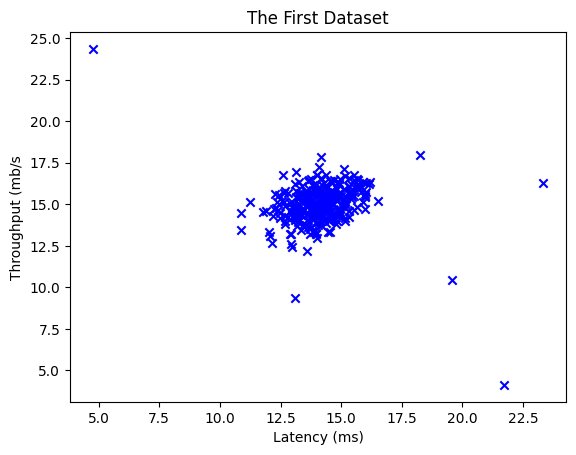

In [18]:
plt.scatter(X_train[:, 0], X_train[:, 1], marker = 'x', color = 'b')


plt.title("The First Dataset")
plt.xlabel('Latency (ms)')
plt.ylabel('Throughput (mb/s')
# plt.axis([0, 30, 0, 30])
plt.show()


In [30]:
def estimate_gaussian(X):

    m, n = X.shape


    mu = 1/m * np.sum(X, axis = 0)
    var = 1/m * np.sum((X - mu) **2, axis = 0)

    # for i in range(m):
    #     u_i += X
    #     u = u_i / m
    #     for j in range(n):
    #         var_i += (X - u) ** 2 
    # var = var_i / m




    return mu, var

In [31]:
mu, var = estimate_gaussian(X_train)

print("mean : ", mu)
print(var)

from public_tests import *
estimate_gaussian_test(estimate_gaussian)

mean :  [14.11222578 14.99771051]
[1.83263141 1.70974533]
All tests passed!


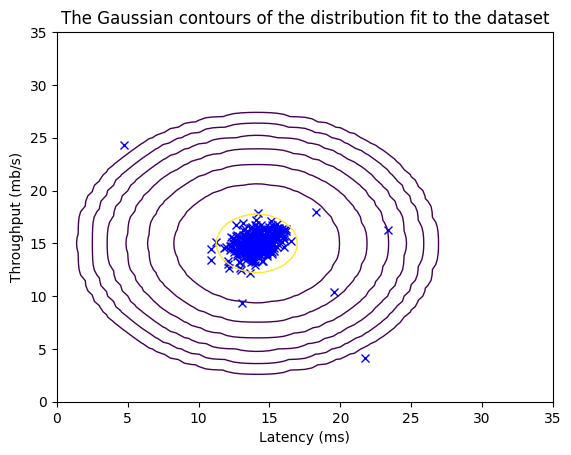

In [34]:
p = multivariate_gaussian(X_train, mu , var)

visualize_fit(X_train, mu, var)

In [36]:
def select_threshold(y_val, p_val):

    best_epsilon = 0
    best_F1 = 0
    F1 = 0

    step_size = (max(p_val) - min(p_val)) / 1000

    for epsilon in np.arange(min(p_val), max(p_val), step_size):
        predictions = p_val < epsilon
        tp = sum((predictions ==1) & (y_val == 1))
        fp = sum((predictions == 1) & (y_val == 0))
        fn = sum((predictions == 0) & (y_val == 1))
        prec = tp / (tp + fp)
        rec = tp / (tp + fn)
        F1 = 2 * (prec * rec) / (prec + rec)



        if F1 > best_F1:
            best_F1 = F1
            best_epsilon = epsilon

    return best_epsilon, best_F1

In [39]:
p_val = multivariate_gaussian(X_val, mu, var)
epsilon, F1 = select_threshold(y_val, p_val)

print('best epsilon using CV : %e' % epsilon)
print('Best f1 on CV set: %f' % F1)

best epsilon using CV : 8.990853e-05
Best f1 on CV set: 0.875000


C:\Users\Errol\AppData\Local\Temp\ipykernel_1544\2220762856.py:14: RuntimeWarning: invalid value encountered in long_scalars
  prec = tp / (tp + fp)


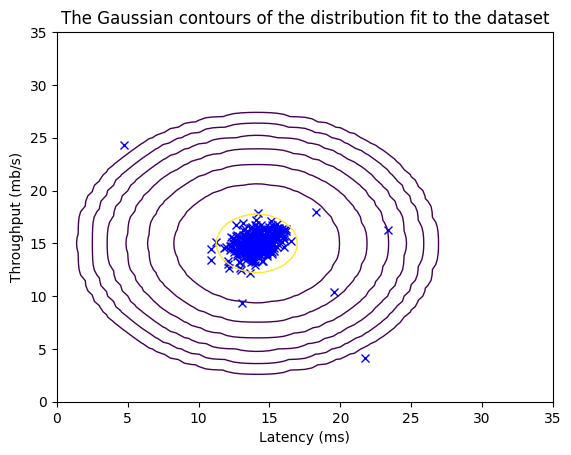

In [41]:
outliers = p < epsilon

visualize_fit(X_train, mu, var)

# plt.plot(X_train[outliers, 0] X_train[outliers, 1]
# , 'ro', markersize = 10, markersize = 10, markerfacecolor = = 'none', markeredgewidth =2)